# Week 2 Mini-Assignment: Autism Spectrum Disorder gut microbiome by Alissa Rivero

**Dataset:** [Human Gut Microbiome with ASD (Kaggle)](https://www.kaggle.com/datasets/antaresnyc/human-gut-microbiome-with-asd/data)

- **A** columns (n = 30) = ASD
- **B** columns (n = 30) = typically developing / healthy controls

Source paper for information on good and bad gut bacteria (used in machine learning models): Dan et al., 2020, *Gut Microbes* / GEO [GSE113690](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE113690) and [GSE113540](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE113540).

## Dataset Abstract

Autistic Spectrum Disorder (ASD) is a severe neurodevelopmental disorder that is primarily characterized by abnormal behavioral symptoms: social interaction impairment, stereotyped behavior, and restricted interests. With its prevalence increasing dramatically over the past decades, ASD now affects 1 out of 59 children in the United States. According to national census data on handicapped individuals, China also has an increased prevalence with ASD first on its list of top mental disabilities.

Accumulating evidences demonstrates that gastrointestinal (GI) symptoms, such as gaseousness, diarrhea, and constipation, often co-occurred with ASD core symptoms in children with ASD. Moreover, recent studies have shown that changes in gut microbiota can modulate the gastrointestinal physiology, immune function, and even behavior through the gut-microbiome-brain axis. Thus, these co-occurring gastrointestinal symptoms have prompted researchers to examine the gut microbial composition of ASD children and determine their potential role in promoting and reflecting ASD symptoms.

## Research Questions

1. Is autism spectrum disorder (ASD) associated with more or less **good** gut bacteria?
2. Is autism spectrum disorder (ASD) associated with more or less **bad** gut bacteria?


## Load and inspect the dataset

In [27]:
import pandas as pd
import statsmodels.api as sm

# Load and inspect: first rows, then dtypes / summary / missing values in the next cells.
df = pd.read_csv("ASD meta abundance.csv")

df.head()

,Taxonomy,A3,A5,A6,A9,A31,A51,A52,A53,A54,...,B120,B127,B132,B141,B142,B143,B152,B156,B158,B164
0,g__Faecalibacterium;s__Faecalibacterium prausn...,4988,5060,2905,5745,4822,3889,4646,6337,5064,...,4471,5868,6561,4910,4492,2812,5303,4205,3430,4563
1,g__Hungatella;s__Hungatella hathewayi,5803,5612,4109,1432,2652,4175,3891,894,4903,...,2126,4429,2598,4222,4925,5753,1261,1822,2478,4868
2,g__Clostridium;s__uncultured Clostridium sp.,3793,2795,1355,5558,5383,3505,5541,4429,4121,...,4085,6041,6188,3960,4403,2841,2746,3808,3856,3211
3,g__Butyricimonas;s__Butyricimonas virosa,64,1385,725,1553,40,53,33,175,58,...,2065,21,27,55,35,8,884,13,3,218
4,g__Alistipes;s__Alistipes indistinctus,15,20,723,620,3261,43,83,37,43,...,90,22,30,1027,2641,4,1587,2223,6,1473


In [28]:
# dtypes, non-null counts, and numeric summary for each sample column
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5619 entries, 0 to 5618
Data columns (total 61 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Taxonomy  5619 non-null   str  
 1   A3        5619 non-null   int64
 2   A5        5619 non-null   int64
 3   A6        5619 non-null   int64
 4   A9        5619 non-null   int64
 5   A31       5619 non-null   int64
 6   A51       5619 non-null   int64
 7   A52       5619 non-null   int64
 8   A53       5619 non-null   int64
 9   A54       5619 non-null   int64
 10  A59       5619 non-null   int64
 11  A67       5619 non-null   int64
 12  A68       5619 non-null   int64
 13  A69       5619 non-null   int64
 14  A71       5619 non-null   int64
 15  A73       5619 non-null   int64
 16  A76       5619 non-null   int64
 17  A78       5619 non-null   int64
 18  A87       5619 non-null   int64
 19  A89       5619 non-null   int64
 20  A93       5619 non-null   int64
 21  A101      5619 non-null   int64
 22  A109      5

,A3,A5,A6,A9,A31,A51,A52,A53,A54,A59,...,B120,B127,B132,B141,B142,B143,B152,B156,B158,B164
count,5619.0000,5619.0000,5619.0000,5619.0000,5619.0000,5619.0000,5619.0000,5619.0000,5619.0000,5619.0000,...,5619.0000,5619.0000,5619.0000,5619.0000,5619.0000,5619.0000,5619.0000,5619.0000,5619.0000,5619.0000
mean,13.0977,15.4104,10.3486,20.8978,17.0333,11.9237,15.5519,16.7129,18.3050,18.8089,...,18.2013,20.5727,20.2411,13.4129,14.8404,8.7469,12.9181,13.7674,10.2093,10.0180
std,143.1268,144.4721,104.2910,165.6745,149.2640,116.7261,149.8133,143.7512,150.1297,154.6068,...,141.0825,174.2809,173.0268,135.5413,145.6207,114.0435,119.8450,120.3614,108.4981,118.3940
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
75%,1.0000,1.0000,1.0000,2.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,...,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000
max,5803.0000,5612.0000,4109.0000,5745.0000,5383.0000,4175.0000,5541.0000,6337.0000,5064.0000,6359.0000,...,4471.0000,6041.0000,6561.0000,4910.0000,4925.0000,5753.0000,5303.0000,4205.0000,3856.0000,4868.0000


In [29]:
# Missing-value counts. Zeros in this table mean the taxon was not detected, not NA.
df.isnull().sum()

Taxonomy    0
A3          0
A5          0
A6          0
A9          0
           ..
B143        0
B152        0
B156        0
B158        0
B164        0
Length: 61, dtype: int64

## Split samples into ASD and control groups

In [30]:
# A columns = ASD participants, B columns = control participants
autism_cols = [c for c in df.columns if c.startswith("A")]
control_cols = [c for c in df.columns if c.startswith("B")]

autism_group = df[["Taxonomy"] + autism_cols]
control_group = df[["Taxonomy"] + control_cols]

print(f"ASD samples: {len(autism_cols)}")
print(f"Control samples: {len(control_cols)}")
display(autism_group.head())
display(control_group.head())

ASD samples: 30
Control samples: 30


,Taxonomy,A3,A5,A6,A9,A31,A51,A52,A53,A54,...,A101,A109,A113,A114,A115,A142,A144,A149,A164,A165
0,g__Faecalibacterium;s__Faecalibacterium prausn...,4988,5060,2905,5745,4822,3889,4646,6337,5064,...,3833,3771,5489,6762,3045,6205,6048,5418,5120,8504
1,g__Hungatella;s__Hungatella hathewayi,5803,5612,4109,1432,2652,4175,3891,894,4903,...,6849,4390,2091,1638,4613,2601,1892,3267,2294,2978
2,g__Clostridium;s__uncultured Clostridium sp.,3793,2795,1355,5558,5383,3505,5541,4429,4121,...,4586,1014,4100,4336,2301,6372,4020,3511,4328,3906
3,g__Butyricimonas;s__Butyricimonas virosa,64,1385,725,1553,40,53,33,175,58,...,3285,30,54,1168,50,38,49,27,1685,838
4,g__Alistipes;s__Alistipes indistinctus,15,20,723,620,3261,43,83,37,43,...,3159,61,2606,2821,21,2276,3,34,2681,2103


,Taxonomy,B1,B2,B3,B5,B6,B7,B8,B13,B14,...,B120,B127,B132,B141,B142,B143,B152,B156,B158,B164
0,g__Faecalibacterium;s__Faecalibacterium prausn...,4269,4397,4499,6126,7020,5404,4404,5811,3360,...,4471,5868,6561,4910,4492,2812,5303,4205,3430,4563
1,g__Hungatella;s__Hungatella hathewayi,1217,6238,2325,5004,2829,2192,2921,4303,2793,...,2126,4429,2598,4222,4925,5753,1261,1822,2478,4868
2,g__Clostridium;s__uncultured Clostridium sp.,3853,4624,3842,4399,3916,3355,5165,4453,1999,...,4085,6041,6188,3960,4403,2841,2746,3808,3856,3211
3,g__Butyricimonas;s__Butyricimonas virosa,1624,1,703,43,46,1505,32,1474,2,...,2065,21,27,55,35,8,884,13,3,218
4,g__Alistipes;s__Alistipes indistinctus,2452,3,819,2761,691,2768,25,1095,13,...,90,22,30,1027,2641,4,1587,2223,6,1473


## `groupby()` summary statistics

Reshape to long format so `groupby()` can use `group` (ASD vs Control) and `genus`.

In [31]:
# Long format so groupby() can summarize by group (ASD vs Control) and by genus.
long_df = df.melt(
    id_vars="Taxonomy",
    var_name="sample",
    value_name="abundance",
)
long_df["group"] = long_df["sample"].map(
    lambda s: "ASD" if s.startswith("A") else "Control"
)
long_df["genus"] = long_df["Taxonomy"].str.extract(r"g__([^;]+)")

group_stats = long_df.groupby("group")["abundance"].agg(["mean", "count", "std"])
group_stats

,mean,count,std
group,,,
ASD,15.9805,168570,142.5635
Control,14.2699,168570,137.4445


In [32]:
genus_stats = (
    long_df.groupby("genus")["abundance"]
    .agg(["mean", "count", "sum"])
    .sort_values("mean", ascending=False)
)
genus_stats.head(15)

,mean,count,sum
genus,,,
Hungatella,3575.3000,60,214518
Faecalibacterium,1223.0833,300,366925
Flavonifractor,868.5833,120,104230
Butyricicoccus,750.9167,120,90110
Bilophila,498.4667,120,59816
Phascolarctobacterium,476.8833,180,85839
Subdoligranulum,414.8667,180,74676
Fusicatenibacter,243.9750,120,29277
Ruthenibacterium,212.3167,60,12739


## Side-by-side ASD vs Control comparison

Mean relative abundance (%) by genus, sorted by percent difference vs Control.

In [33]:
# Relative abundance: each sample's counts divided by that sample's total reads.
rel = df.set_index("Taxonomy")
rel = rel.div(rel.sum(axis=0), axis=1)

long_rel = rel.reset_index().melt(
    id_vars="Taxonomy",
    var_name="sample",
    value_name="rel_abundance",
)
long_rel["group"] = long_rel["sample"].map(
    lambda s: "ASD" if s.startswith("A") else "Control"
)
long_rel["genus"] = long_rel["Taxonomy"].str.extract(r"g__([^;]+)")

comparison = long_rel.groupby(["genus", "group"])["rel_abundance"].mean().unstack()
comparison["percent_diff"] = (
    (comparison["ASD"] - comparison["Control"]) / comparison["Control"] * 100
)
comparison = comparison.replace([float("inf"), float("-inf")], pd.NA)
comparison = comparison.dropna(subset=["percent_diff"])
comparison["abs_percent_diff"] = comparison["percent_diff"].abs()
comparison = comparison.sort_values("abs_percent_diff", ascending=False)

comparison_out = comparison.copy()
comparison_out["ASD"] = comparison_out["ASD"] * 100
comparison_out["Control"] = comparison_out["Control"] * 100

pd.set_option("display.max_rows", 30)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

cols = ["ASD", "Control", "percent_diff", "abs_percent_diff"]
comparison_out[cols].head(30)

group,ASD,Control,percent_diff,abs_percent_diff
genus,,,,
Thiomicrospira,0.0002,0.0000,2382.3512,2382.3512
Crocosphaera,0.0009,0.0000,2296.0009,2296.0009
Cba41virus,0.0005,0.0000,1713.0469,1713.0469
Mitsuaria,0.0004,0.0000,1327.8834,1327.8834
Alloprevotella,0.0156,0.0011,1297.1598,1297.1598
Algibacter,0.0004,0.0000,1086.0357,1086.0357
Silviavirus,0.0004,0.0000,993.5691,993.5691
Mycoplasma,0.0053,0.0005,900.5307,900.5307
Synechococcus,0.0001,0.0000,864.4169,864.4169


### Filter to genera with ASD or Control > 0.01%

In [34]:
# Keep genera that reach at least 0.01% in ASD or Control.
filtered = comparison_out[
    (comparison_out["ASD"] > 0.01) | (comparison_out["Control"] > 0.01)
]
filtered[cols].head(30)

group,ASD,Control,percent_diff,abs_percent_diff
genus,,,,
Alloprevotella,0.0156,0.0011,1297.1598,1297.1598
Holdemanella,0.1065,0.0231,360.5245,360.5245
Desulfovibrio,0.0103,0.0024,338.4170,338.4170
Sutterella,0.0828,0.0259,219.4573,219.4573
Prevotella,0.0251,0.0088,186.3703,186.3703
Paraprevotella,0.0961,0.0340,182.7693,182.7693
Chlamydia,0.0313,0.0142,120.3395,120.3395
Candidatus Stoquefichus,0.0175,0.0084,108.3185,108.3185
Azospirillum,0.0281,0.0138,103.4955,103.4955


### Higher vs lower in ASD

In [35]:
# Split remaining genera by whether mean relative abundance is higher or lower in ASD.
higher_in_asd = filtered[filtered["percent_diff"] > 0]
lower_in_asd = filtered[filtered["percent_diff"] < 0]

print("Higher in ASD")
display(higher_in_asd[cols].head(30))
print("Lower in ASD")
display(lower_in_asd[cols].head(30))

Higher in ASD


group,ASD,Control,percent_diff,abs_percent_diff
genus,,,,
Alloprevotella,0.0156,0.0011,1297.1598,1297.1598
Holdemanella,0.1065,0.0231,360.5245,360.5245
Desulfovibrio,0.0103,0.0024,338.4170,338.4170
Sutterella,0.0828,0.0259,219.4573,219.4573
Prevotella,0.0251,0.0088,186.3703,186.3703
Paraprevotella,0.0961,0.0340,182.7693,182.7693
Chlamydia,0.0313,0.0142,120.3395,120.3395
Candidatus Stoquefichus,0.0175,0.0084,108.3185,108.3185
Azospirillum,0.0281,0.0138,103.4955,103.4955


Lower in ASD


group,ASD,Control,percent_diff,abs_percent_diff
genus,,,,
Acidiphilium,0.0056,0.0115,-51.0082,51.0082
Intestinibacter,0.0369,0.0642,-42.5393,42.5393
Youngiibacter,0.0104,0.0175,-40.4910,40.4910
Allisonella,0.0352,0.0590,-40.3048,40.3048
Dialister,0.0481,0.0791,-39.1418,39.1418
Coprobacillus,0.0279,0.0439,-36.4072,36.4072
Salmonella,0.0095,0.0149,-36.1229,36.1229
Bifidobacterium,0.0088,0.0132,-32.9271,32.9271
Escherichia,0.1540,0.2260,-31.8716,31.8716


## Good vs bad bacteria scores

Per-sample sums of relative abundance for beneficial or harmful bacteria taxa. Based on the cited paper.

In [36]:
# Paper-based beneficial vs harmful taxa. A taxon listed as harmful wins if both apply.
GOOD_GENERA = {
    "Bifidobacterium",
    "Lactobacillus",
    "Faecalibacterium",
    "Roseburia",
    "Ruminococcus",
    "Bacteroides",
    "Prevotella",
}
BAD_GENERA = {
    "Salmonella",
    "Shigella",
    "Klebsiella",
    "Serratia",
    "Pseudomonas",
    "Campylobacter",
    "Desulfovibrio",
    "Enterobacter",
    "Citrobacter",
    "Proteus",
    "Yersinia",
    "Fusobacterium",
    "Leptotrichia",
    "Veillonella",
    "Megamonas",
    "Megasphaera",
    "Dialister",
    "Allisonella",
}


def taxon_genus(tax):
    if tax.startswith("g__"):
        return tax.split(";")[0].removeprefix("g__")
    return ""


def is_gnavus(tax):
    return "gnavus" in tax.lower()


def is_bad_taxon(tax):
    genus = taxon_genus(tax)
    if is_gnavus(tax):
        return True
    if "Clostridioides difficile" in tax:
        return True
    if tax.endswith("s__Escherichia coli"):
        return True
    return genus in BAD_GENERA


def is_good_taxon(tax):
    if is_bad_taxon(tax):
        return False
    genus = taxon_genus(tax)
    if genus in GOOD_GENERA:
        return True
    return "Oxalobacter formigenes" in tax


good_taxa = df.loc[df["Taxonomy"].map(is_good_taxon), "Taxonomy"]
bad_taxa = df.loc[df["Taxonomy"].map(is_bad_taxon), "Taxonomy"]

print(f"n_good_taxa: {len(good_taxa)}")
print(f"n_bad_taxa: {len(bad_taxa)}")
print("Unmatched paper names: Helicobacter hepaticus")

n_good_taxa: 409
n_bad_taxa: 253
Unmatched paper names: Helicobacter hepaticus


In [37]:
# Per-sample composite scores: sum of relative abundance over matched good / bad taxa.
sample_df = pd.DataFrame(
    {
        "sample": rel.columns,
        "autism": [1 if c.startswith("A") else 0 for c in rel.columns],
        "good_bacteria": rel.loc[good_taxa].sum(axis=0).values,
        "bad_bacteria": rel.loc[bad_taxa].sum(axis=0).values,
    }
)
sample_df.groupby("autism")[["good_bacteria", "bad_bacteria"]].agg(
    ["mean", "count", "std"]
)

good_bacteria              bad_bacteria             
                mean count    std         mean count    std
autism                                                     
0             0.2452    30 0.0319       0.0301    30 0.0135
1             0.2869    30 0.0442       0.0281    30 0.0123

## Prediction models

`good_bacteria ~ autism` and `bad_bacteria ~ autism` (autism = 1 for ASD, 0 for control).

In [38]:
# OLS: autism (1 = ASD, 0 = control) predicting the good-bacteria score.
X = sm.add_constant(sample_df["autism"])
good_model = sm.OLS(sample_df["good_bacteria"], X).fit()
good_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          good_bacteria   R-squared:                       0.232
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     17.53
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           9.75e-05
Time:                        21:02:44   Log-Likelihood:                 111.24
No. Observations:                  60   AIC:                            -218.5
Df Residuals:                      58   BIC:                            -214.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2452      0.007     34.848      0.000       0.231       0.259
autism         0.0417      0.010      4.186      0.000       0.022       0.062
==============================================================================
Omnibus:                        0.042   Durbin-Watson:                   1.758
Prob(Omnibus):                  0.979   Jarque-Bera (JB):                0.201
Skew:                           0.043   Prob(JB):                        0.904
Kurtosis:                       2.730   Cond. No.                         2.62
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Interpretation: good bacteria

**Question 1: Is ASD associated with more or less good gut bacteria?**  
In this sample, **more.**

- **const = 0.245:** controls have about 24.5% of reads in the beneficial taxa on average.
- **autism = +0.042:** ASD samples are about **4.2 percentage points higher** (roughly 28.7% of reads). The 95% CI is 0.022 to 0.062, so the interval stays above zero.
- **p < 0.001** and **R² = 0.23:** the ASD vs control difference is statistically significant and explains about 23% of the variation in the good-bacteria score.

In [39]:
# Same OLS specification for the bad-bacteria score.
bad_model = sm.OLS(sample_df["bad_bacteria"], X).fit()
bad_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           bad_bacteria   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.011
Method:                 Least Squares   F-statistic:                    0.3433
Date:                Thu, 10 Sep 2026   Prob (F-statistic):              0.560
Time:                        21:02:44   Log-Likelihood:                 176.88
No. Observations:                  60   AIC:                            -349.8
Df Residuals:                      58   BIC:                            -345.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0301      0.002     12.761      0.000       0.025       0.035
autism        -0.0020      0.003     -0.586      0.560      -0.009       0.005
==============================================================================
Omnibus:                       19.512   Durbin-Watson:                   1.525
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               26.796
Skew:                           1.238   Prob(JB):                     1.52e-06
Kurtosis:                       5.143   Cond. No.                         2.62
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Interpretation: bad bacteria

**Question 2: Is ASD associated with more or less bad gut bacteria?**  
**No clear difference** in this sample.

- **const = 0.030:** controls have about 3.0% of reads in the harmful taxa on average.
- **autism = −0.002:** ASD samples are about **0.2 percentage points lower**. The 95% CI is −0.009 to 0.005 and **crosses zero**.
- **p = 0.56** and **R² = 0.006:** autism does not significantly predict the bad-bacteria score. The model explains almost none of the variation.

**Takeaway:** ASD is linked to a **higher beneficial-taxon score** and **not** to a higher (or lower) harmful-taxon score in these 60 metagenomes. That does not match a simple “ASD = more pathogens / fewer probiotics” story, and it should not be read as a clinical test.


## Visualization

A **boxplot plus strip plot** is the right chart here: two groups, a continuous score, and n = 30 samples per group. The box shows the distribution (median and spread). The points keep every sample visible so a mean is not hiding outliers. Each panel has its own y-axis because the bad-bacteria score is a much smaller share of reads than the good-bacteria score.

Each point is one stool sample. Olive panels show beneficial taxa; mauve panels show harmful taxa.


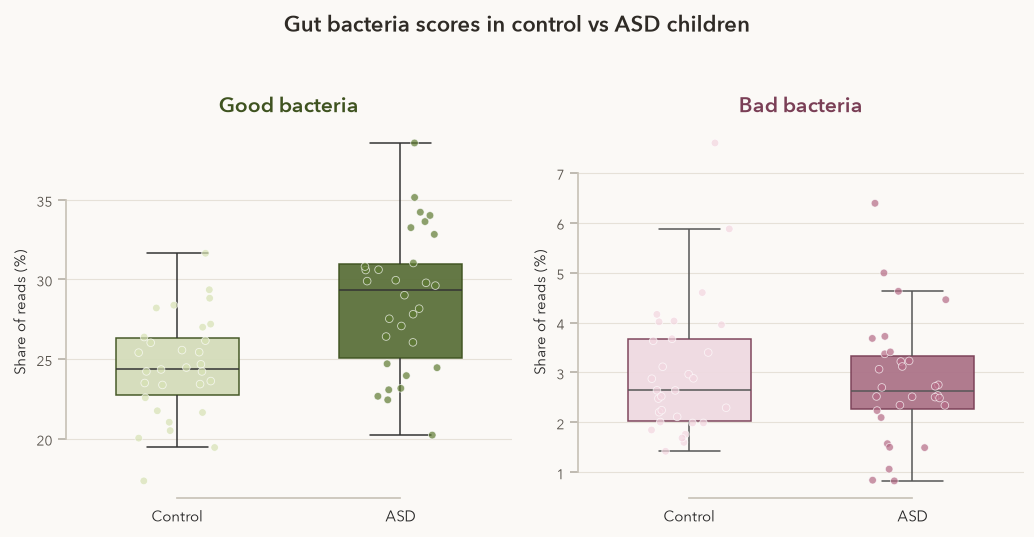

In [ ]:
# Boxplot + strip: two groups, continuous scores, n = 30 each. The box shows
# the distribution; points keep every sample visible. Separate y-axes because
# the bad-bacteria score is a much smaller share of reads.
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", context="notebook")
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": [
            "Avenir Next",
            "Avenir",
            "Helvetica Neue",
            "Arial",
            "DejaVu Sans",
        ],
        "axes.titlesize": 15,
        "axes.titleweight": "semibold",
        "axes.labelsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 10,
    }
)

plot_df = sample_df.copy()
plot_df["group"] = plot_df["autism"].map({0: "Control", 1: "ASD"})
plot_df["Good bacteria"] = plot_df["good_bacteria"] * 100
plot_df["Bad bacteria"] = plot_df["bad_bacteria"] * 100

panels = [
    ("Good bacteria", {"Control": "#D7E2B4", "ASD": "#5E7A32"}, "#3F5320"),
    ("Bad bacteria", {"Control": "#F3D6E0", "ASD": "#B56B86"}, "#7A3F56"),
]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 5.2), facecolor="#FBF9F6")
fig.patch.set_facecolor("#FBF9F6")

for ax, (col, palette, edge) in zip(axes, panels):
    ax.set_facecolor("#FBF9F6")
    sns.boxplot(
        data=plot_df,
        x="group",
        y=col,
        hue="group",
        hue_order=["Control", "ASD"],
        order=["Control", "ASD"],
        palette=palette,
        width=0.55,
        linewidth=1.1,
        fliersize=0,
        legend=False,
        ax=ax,
    )
    for patch in ax.patches:
        patch.set_edgecolor(edge)
        patch.set_linewidth(1.1)
        patch.set_alpha(0.95)
    sns.stripplot(
        data=plot_df,
        x="group",
        y=col,
        hue="group",
        hue_order=["Control", "ASD"],
        order=["Control", "ASD"],
        palette=palette,
        legend=False,
        jitter=0.18,
        size=5.5,
        alpha=0.7,
        linewidth=0.6,
        edgecolor="white",
        ax=ax,
    )
    ax.set_title(col, pad=10, color=edge)
    ax.set_xlabel("")
    ax.set_ylabel("Share of reads (%)")
    ax.tick_params(axis="x", length=0, pad=6)
    ax.tick_params(axis="y", color="#B8B2A8", labelcolor="#5A554E")
    sns.despine(ax=ax, trim=True)
    ax.spines["left"].set_color("#C9C3B8")
    ax.spines["bottom"].set_color("#C9C3B8")
    ax.yaxis.grid(True, color="#E6E1D8", linewidth=0.8)
    ax.set_axisbelow(True)

fig.suptitle(
    "Gut bacteria scores in control vs ASD children",
    y=1.03,
    fontsize=16,
    fontweight="semibold",
    color="#2F2B26",
)
fig.tight_layout()
plt.show()

## Pandas vs Polars (same pipeline)

The analysis above is Pandas. The same load → relative abundance → genus × group mean can be written in Polars. Times below are the mean of 7 runs after one warmup, on this 5,619 × 60 table.

In [1]:
# Same load / relative-abundance / genus-mean pipeline in Pandas and Polars.
from pathlib import Path
from time import perf_counter
import pandas as pd
import polars as pl

DATA_PATH = Path("ASD meta abundance.csv")


def _repeat(fn, n=7, warmup=1):
    for _ in range(warmup):
        fn()
    times = []
    for _ in range(n):
        start = perf_counter()
        fn()
        times.append(perf_counter() - start)
    return sum(times) / len(times)


def pandas_pipeline():
    pdf = pd.read_csv(DATA_PATH)
    sample_cols = [c for c in pdf.columns if c != "Taxonomy"]
    totals = pdf[sample_cols].sum(axis=0)
    rel_pdf = pdf[sample_cols].div(totals, axis=1)
    long = rel_pdf.assign(Taxonomy=pdf["Taxonomy"]).melt(
        id_vars="Taxonomy", var_name="sample", value_name="rel_abundance"
    )
    long["group"] = long["sample"].map(
        lambda s: "ASD" if s.startswith("A") else "Control"
    )
    long["genus"] = long["Taxonomy"].str.extract(r"g__([^;]+)")
    return long.groupby(["genus", "group"])["rel_abundance"].mean().unstack()


def polars_pipeline():
    pdf = pl.read_csv(DATA_PATH)
    sample_cols = [c for c in pdf.columns if c != "Taxonomy"]
    totals = pdf.select([pl.col(c).sum().alias(c) for c in sample_cols])
    rel_pdf = pdf.select(
        ["Taxonomy"]
        + [(pl.col(c) / totals.get_column(c)[0]).alias(c) for c in sample_cols]
    )
    long = rel_pdf.unpivot(
        index="Taxonomy", variable_name="sample", value_name="rel_abundance"
    ).with_columns(
        pl.when(pl.col("sample").str.starts_with("A"))
        .then(pl.lit("ASD"))
        .otherwise(pl.lit("Control"))
        .alias("group"),
        pl.col("Taxonomy").str.extract(r"g__([^;]+)", 1).alias("genus"),
    )
    return (
        long.group_by(["genus", "group"])
        .agg(pl.col("rel_abundance").mean())
        .pivot(values="rel_abundance", index="genus", on="group")
    )


pandas_s = _repeat(pandas_pipeline)
polars_s = _repeat(polars_pipeline)
pandas_cmp = pandas_pipeline()
polars_rows = {row["genus"]: row for row in polars_pipeline().to_dicts()}
diffs = []
for genus, row in pandas_cmp.iterrows():
    other = polars_rows.get(genus)
    if other is None:
        continue
    for col in ("ASD", "Control"):
        if other.get(col) is None:
            continue
        diffs.append(abs(float(row[col]) - float(other[col])))

print(f"Pandas mean time: {pandas_s * 1000:.1f} ms")
print(f"Polars mean time: {polars_s * 1000:.1f} ms")
print(f"Speedup (Pandas / Polars): {pandas_s / polars_s:.2f}x")
print(f"Max abs difference on overlapping genera: {max(diffs):.3e}")

Pandas mean time: 277.1 ms
Polars mean time: 97.6 ms
Speedup (Pandas / Polars): 2.84x
Max abs difference on overlapping genera: 4.337e-19


On this machine the same pipeline was about **280 ms in Pandas** and **98 ms in Polars** (~**3×**). The genus means match to floating-point noise (max absolute difference ~10⁻¹⁹). Polars is faster because the engine is compiled Rust — the same idea as the Question 2 notebook. The scientific results above still come from the Pandas / statsmodels models.